# 第 0 步：环境准备与库导入

这一部分负责导入需要的库。

如果你还没有安装依赖，可以在终端中运行：

```bash
python -m pip install tensorflow matplotlib numpy
```

如果你使用的是 Jupyter Notebook，也可以新建一个代码单元格运行：

```python
!python -m pip install tensorflow matplotlib numpy
```

---

## 说明

这里我们会使用：

- `tensorflow`：构建和训练神经网络
- `tf.keras`：TensorFlow 内置的 Keras 高级神经网络接口
- `numpy`：处理数组和矩阵
- `matplotlib`：绘图和可视化
- `random`：固定随机种子，方便结果尽量一致


In [2]:
# ============================================================
# 第 0 步：环境准备与库导入
# ============================================================

import os

# ------------------------------------------------------------
# 重要设置 1：
# 强制 Keras 使用 TensorFlow 作为后端。
#
# 这行代码必须放在 import tensorflow 之前。
# 这是为了避免某些环境中 Keras 后端被错误设置成 mxnet、jax 或 torch。
# ------------------------------------------------------------
os.environ["KERAS_BACKEND"] = "tensorflow"

# ------------------------------------------------------------
# 重要设置 2：
# 减少 TensorFlow 的运行日志输出。
# 这不会影响程序结果，只是让展示时终端更干净。
# ------------------------------------------------------------
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# ------------------------------------------------------------
# 推荐写法：
# 通过 tf.keras 使用 Keras。
#
# 这样比 from tensorflow.keras import layers 更稳，
# 可以减少 VS Code / Pylance 对 tensorflow.keras 解析失败的问题。
# ------------------------------------------------------------
keras = tf.keras
layers = tf.keras.layers

print("TensorFlow 版本：", tf.__version__)
print("Keras 接口：", keras)


TensorFlow 版本： 2.21.0
Keras 接口： <module 'keras._tf_keras.keras' from '/Users/zhangzixin/tf_env/lib/python3.12/site-packages/keras/_tf_keras/keras/__init__.py'>


# 第 0.1 步：设置中文字体

如果你的图表标题、坐标轴中的中文显示为方框，通常是因为 Matplotlib 没有找到中文字体。

下面的代码会尽量优先使用 macOS 常见中文字体：

- `PingFang SC`
- `Heiti SC`
- `Arial Unicode MS`

也兼容 Windows 常见字体：

- `Microsoft YaHei`
- `SimHei`


In [3]:
# ============================================================
# 第 0.1 步：设置 Matplotlib 中文字体
# ============================================================

def set_chinese_font():
    """
    设置 matplotlib 中文字体，尽量避免中文乱码。

    注意：
    1. 不同电脑安装的中文字体可能不同。
    2. matplotlib 会从列表中依次寻找可用字体。
    3. 如果你发现中文仍然乱码，可以把自己电脑中的中文字体名称加入这个列表。
    """
    plt.rcParams["font.sans-serif"] = [
        "PingFang SC",        # macOS 常见中文字体
        "Heiti SC",           # macOS 常见中文字体
        "Arial Unicode MS",   # macOS / Windows 可能存在
        "Microsoft YaHei",    # Windows 微软雅黑
        "SimHei"              # Windows 黑体
    ]

    # 解决负号显示成方块的问题
    plt.rcParams["axes.unicode_minus"] = False


set_chinese_font()

print("中文字体设置完成。")


中文字体设置完成。


# 第 1 步：加载 MNIST 数据集

MNIST 是机器学习中非常经典的手写数字数据集。

它包含：

- 60,000 张训练图片
- 10,000 张测试图片
- 每张图片大小为 28 × 28
- 图片是灰度图，不是彩色图
- 每张图片对应一个标签，标签是 0 到 9 中的一个数字

---

```text
很多样本 + 每个样本对应的答案
```

在 MNIST 中：

```text
样本 = 一张 28×28 的手写数字图片
答案 = 这张图片对应的真实数字标签
```


In [6]:
# ============================================================
# 第 1 步：加载 MNIST 数据集
# ============================================================

# keras.datasets.mnist.load_data() 会自动下载并读取 MNIST 数据集。
#
# 返回值结构：
# (x_train_full, y_train_full), (x_test, y_test)
#
# x_train_full：训练图片
# y_train_full：训练图片对应的标签
# x_test：测试图片
# y_test：测试图片对应的标签
#
# 注意：
# 第一次运行时，如果本地没有 MNIST 数据集，会自动联网下载。
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()

print("训练图片 x_train_full 的形状：", x_train_full.shape)
print("训练标签 y_train_full 的形状：", y_train_full.shape)
print("测试图片 x_test 的形状：", x_test.shape)
print("测试标签 y_test 的形状：", y_test.shape)

print("\n解释：")
print("x_train_full.shape = (60000, 28, 28)")
print("表示训练集中有 60000 张图片，每张图片是一个 28 行、28 列的像素矩阵。")

print("\ny_train_full.shape = (60000,)")
print("表示训练集中有 60000 个标签，每张图片对应一个真实答案。")

print("\nx_test.shape = (10000, 28, 28)")
print("表示测试集中有 10000 张图片，每张图片也是 28×28。")


训练图片 x_train_full 的形状： (60000, 28, 28)
训练标签 y_train_full 的形状： (60000,)
测试图片 x_test 的形状： (10000, 28, 28)
测试标签 y_test 的形状： (10000,)

解释：
x_train_full.shape = (60000, 28, 28)
表示训练集中有 60000 张图片，每张图片是一个 28 行、28 列的像素矩阵。

y_train_full.shape = (60000,)
表示训练集中有 60000 个标签，每张图片对应一个真实答案。

x_test.shape = (10000, 28, 28)
表示测试集中有 10000 张图片，每张图片也是 28×28。


# 第 2 步：展示一批原始手写数字图片

这一部分不是训练模型，而是直观看到数据长什么样。

机器学习教学中非常重要的一点是：

> 不要一上来就写模型，先观察数据。

如果连数据是什么样子都没有看过，就很难理解模型到底在学什么。


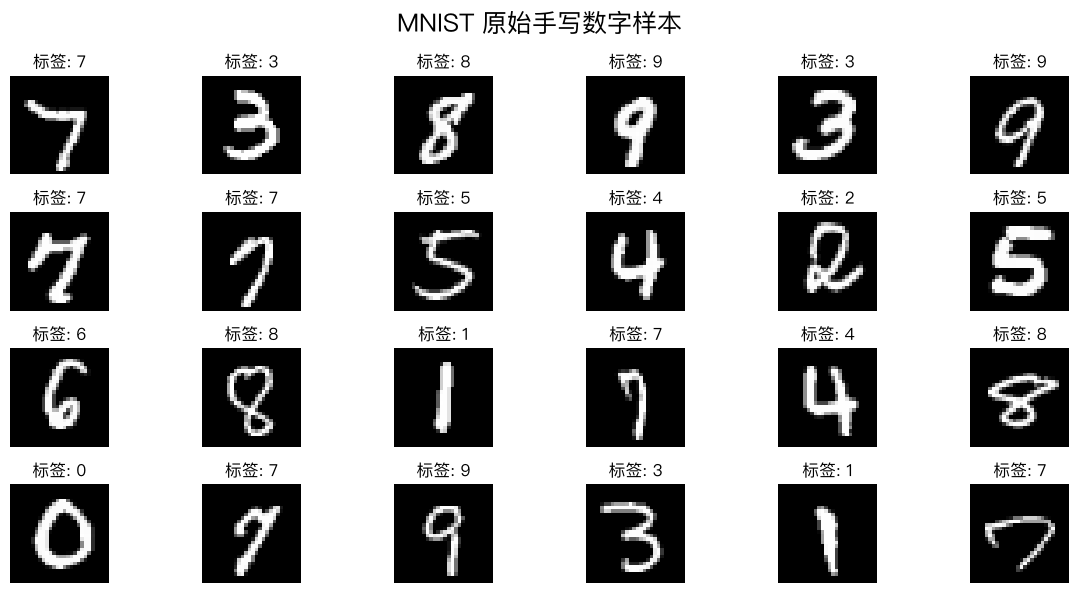

In [7]:
# ============================================================
# 第 2 步：展示 MNIST 中的一批原始手写数字图片
# ============================================================

# 固定随机种子，让每次随机抽取的图片尽量一致。
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 从 60000 张训练图片中，随机抽取 24 张进行展示。
sample_indices = np.random.choice(len(x_train_full), size=24, replace=False)

plt.figure(figsize=(12, 6))

for i, idx in enumerate(sample_indices):
    plt.subplot(4, 6, i + 1)

    # cmap="gray" 表示按照灰度图显示。
    # MNIST 是灰度图，因此不需要 RGB 三个通道。
    plt.imshow(x_train_full[idx], cmap="gray")

    # 每张图上方显示真实标签。
    plt.title(f"标签: {y_train_full[idx]}")

    # 不显示坐标轴，让图片更清晰。
    plt.axis("off")

plt.suptitle("MNIST 原始手写数字样本", fontsize=18)
plt.tight_layout()
plt.show()


# 第 3 步：观察一张图片背后的 28×28 像素矩阵

你看到的是一张图片，但计算机看到的是一个数字矩阵。

MNIST 中每张图片都是：

```text
28 行 × 28 列 = 784 个像素点
```

每个像素点的值大约表示这个位置的亮度：

```text
0   表示黑色
255 表示白色
中间值表示不同程度的灰色
```


我们选择第 0 张训练图片进行观察。
这张图片的真实标签是： 5
这张图片的形状是： (28, 28)

这张图片对应的 28×28 像素矩阵如下：
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   

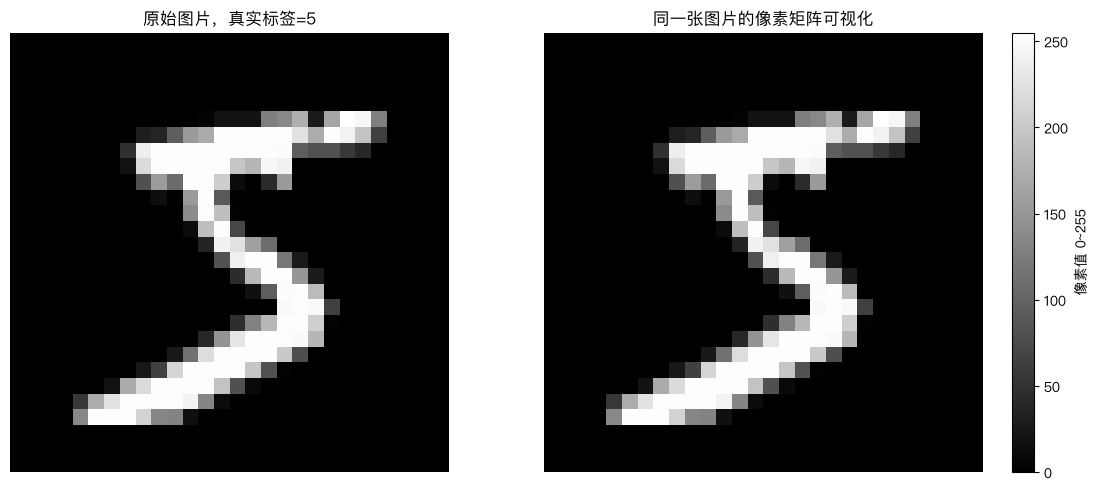

In [8]:
# ============================================================
# 第 3 步：选择一张图片，观察它背后的像素矩阵
# ============================================================

# 选择第 0 张训练图片进行详细观察。
example_index = 0

# 取出这张图片和它的真实标签。
example_image = x_train_full[example_index]
example_label = y_train_full[example_index]

print(f"我们选择第 {example_index} 张训练图片进行观察。")
print("这张图片的真实标签是：", example_label)
print("这张图片的形状是：", example_image.shape)

print("\n这张图片对应的 28×28 像素矩阵如下：")
print(example_image)

# 用图像方式显示这张图片。
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(example_image, cmap="gray")
plt.title(f"原始图片，真实标签={example_label}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(example_image, cmap="gray")
plt.title("同一张图片的像素矩阵可视化")
plt.colorbar(label="像素值 0~255")
plt.axis("off")

plt.tight_layout()
plt.show()


# 第 4 步：把图片放大，并标出每个像素点的数值

这一步用于帮助你建立一个关键概念：

> 图片 = 像素矩阵 = 很多数值

这张图会把一张 28×28 图片放大，并在非黑色像素上标出对应的像素值。

---

## 教学提示

如果你会问：

> 为什么有些位置是 0，有些位置是 255？

你可以解释：

- 背景区域通常接近 0
- 手写笔画区域通常更亮，数值更大
- 笔画边缘可能是灰色，所以会出现 30、80、150 这种中间值


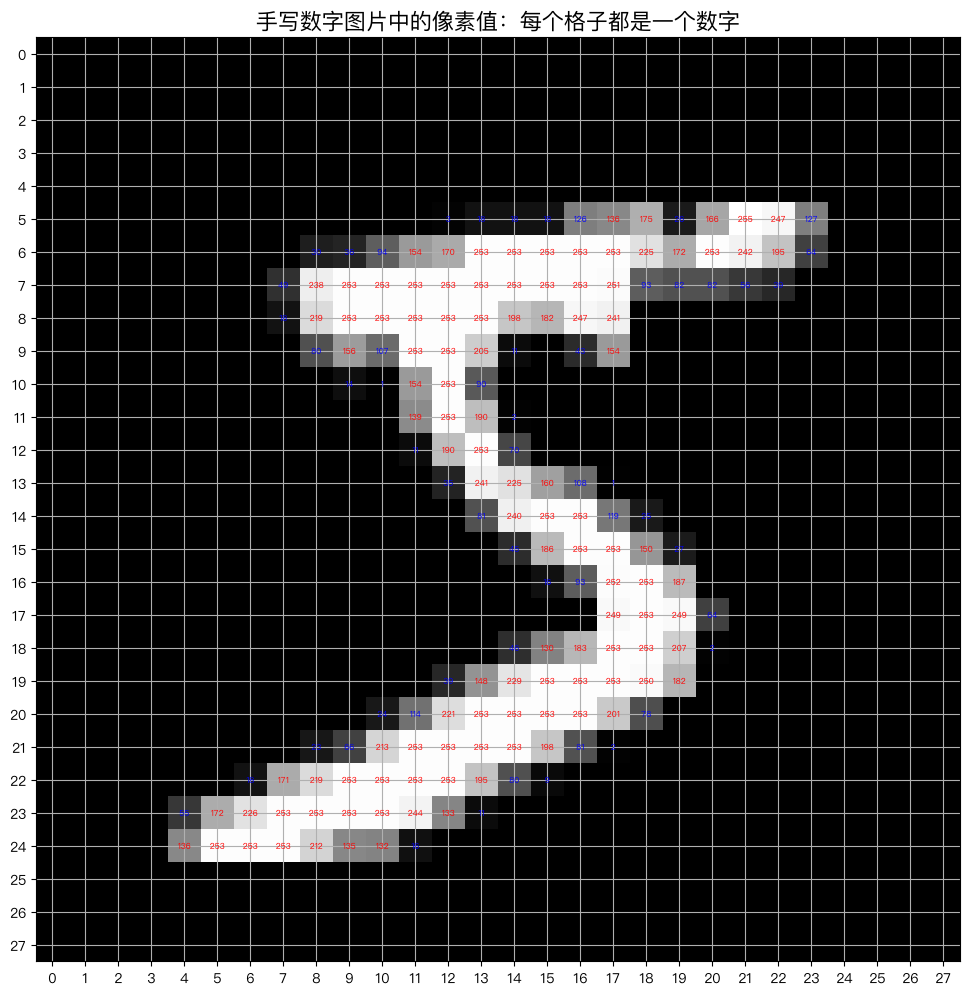

In [9]:
# ============================================================
# 第 4 步：放大展示每个像素点的数值
# ============================================================

plt.figure(figsize=(12, 12))

# 显示原始图片。
plt.imshow(example_image, cmap="gray")

# 遍历 28 行、28 列中的每一个像素。
for row in range(28):
    for col in range(28):
        value = example_image[row, col]

        # 为了避免图太乱，这里只显示非零像素。
        # 如果你想显示所有像素，可以删除下面这个 if 条件。
        if value > 0:
            plt.text(
                col,                # x 坐标，也就是列
                row,                # y 坐标，也就是行
                str(value),         # 显示的文字，也就是像素值
                ha="center",        # 水平居中
                va="center",        # 垂直居中
                fontsize=6,
                color="red" if value > 128 else "blue"
            )

plt.title("手写数字图片中的像素值：每个格子都是一个数字", fontsize=16)
plt.xticks(range(28))
plt.yticks(range(28))
plt.grid()
plt.show()


# 第 5 步：数据归一化

原始图片中的像素值范围是：

```text
0 到 255
```

神经网络训练时通常更喜欢较小、稳定的数值范围。  
因此我们通常会把像素值除以 255，使其变成：

```text
0 到 1
```

例如：

```text
0   / 255 = 0
255 / 255 = 1
128 / 255 ≈ 0.502
```

---

## 为什么要归一化？

可以这样解释：

> 如果输入数字太大，模型训练时参数更新可能不稳定；  
> 把输入压缩到 0~1 范围内，训练通常更平稳。


归一化前：
最小值： 0
最大值： 255

归一化后：
最小值： 0.0
最大值： 1.0


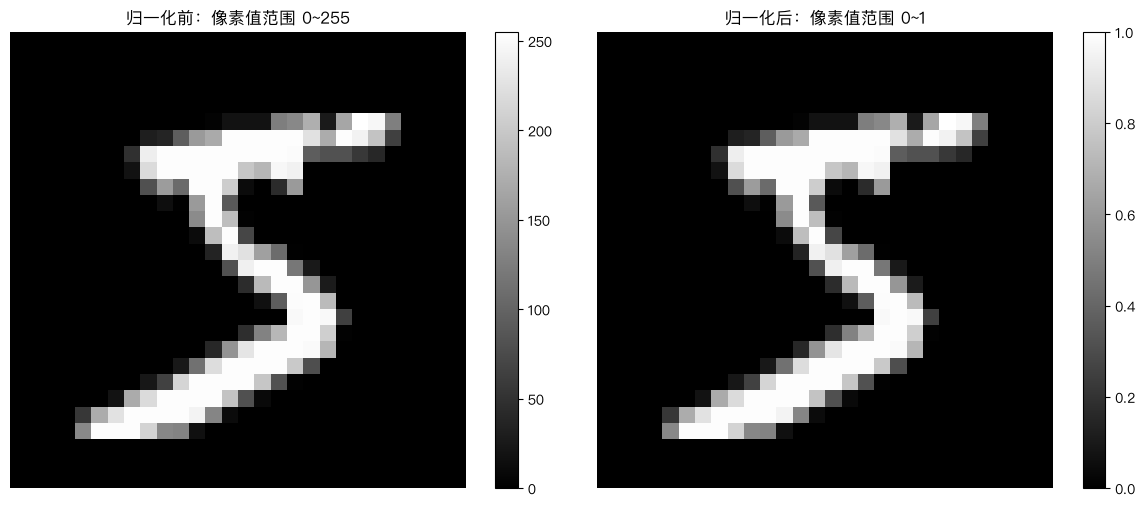

In [10]:
# ============================================================
# 第 5 步：数据归一化，把像素值从 0~255 转换成 0~1
# ============================================================

# astype("float32")：
# 把整数类型转成浮点数类型。
#
# / 255.0：
# 把所有像素值缩放到 0~1。
x_train_full_normalized = x_train_full.astype("float32") / 255.0
x_test_normalized = x_test.astype("float32") / 255.0

# 取出同一张图片的归一化结果。
example_image_normalized = x_train_full_normalized[example_index]

print("归一化前：")
print("最小值：", example_image.min())
print("最大值：", example_image.max())

print("\n归一化后：")
print("最小值：", example_image_normalized.min())
print("最大值：", example_image_normalized.max())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(example_image, cmap="gray")
plt.title("归一化前：像素值范围 0~255")
plt.colorbar()
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(example_image_normalized, cmap="gray")
plt.title("归一化后：像素值范围 0~1")
plt.colorbar()
plt.axis("off")

plt.tight_layout()
plt.show()


# 第 6 步：拆分训练集和验证集

原始 MNIST 已经给了：

- 训练集
- 测试集

但是在训练过程中，我们还希望有一部分数据专门用来观察模型表现，这部分叫做：

```text
验证集 validation set
```

---

## 三种数据集的区别

| 数据集 | 作用 |
|---|---|
| 训练集 | 真正用来训练模型、调整参数 |
| 验证集 | 训练过程中观察模型是否学得好 |
| 测试集 | 训练结束后，最终检查模型效果 |

---

## 为什么不能只用训练集？

如果模型在训练集上表现很好，不代表它真的学会了规律。  
它可能只是“背下了训练集”。

验证集和测试集的作用就是检查：

> 模型能不能识别没见过的新图片？


In [11]:
# ============================================================
# 第 6 步：拆分训练集和验证集
# ============================================================

# 先生成一个随机排列的索引数组。
# 这样可以把训练集顺序打乱。
indices = np.random.permutation(len(x_train_full_normalized))

# 根据随机索引重新排列图片和标签。
x_train_full_normalized = x_train_full_normalized[indices]
y_train_full = y_train_full[indices]

# 从 60000 张训练图片中，取最后 10000 张作为验证集。
x_val = x_train_full_normalized[-10000:]
y_val = y_train_full[-10000:]

# 前 50000 张作为真正的训练集。
x_train = x_train_full_normalized[:-10000]
y_train = y_train_full[:-10000]

print("训练集图片形状：", x_train.shape)
print("训练集标签形状：", y_train.shape)
print("验证集图片形状：", x_val.shape)
print("验证集标签形状：", y_val.shape)
print("测试集图片形状：", x_test_normalized.shape)
print("测试集标签形状：", y_test.shape)


训练集图片形状： (50000, 28, 28)
训练集标签形状： (50000,)
验证集图片形状： (10000, 28, 28)
验证集标签形状： (10000,)
测试集图片形状： (10000, 28, 28)
测试集标签形状： (10000,)


# 第 7 步：理解标签和 one-hot 编码

MNIST 的标签本来是一个普通数字，例如：

```text
5
```

表示这张图片的真实数字是 5。

但是在分类任务中，我们也经常会看到 one-hot 编码。

例如标签 5 可以表示成：

```text
[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
```

它的意思是：

- 不是 0
- 不是 1
- 不是 2
- 不是 3
- 不是 4
- 是 5
- 不是 6
- 不是 7
- 不是 8
- 不是 9

---

## 注意

本 Notebook 训练时使用的损失函数是：

```python
sparse_categorical_crossentropy
```

这个损失函数可以直接接收整数标签，所以训练时不需要手动 one-hot。  
这里展示 one-hot 只是为了帮助理解分类任务。


原始标签： 5
one-hot 编码： [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


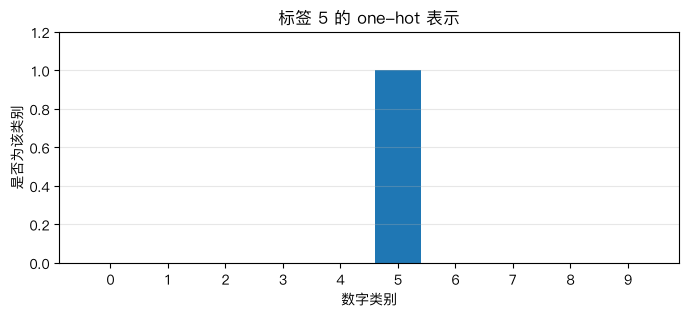

In [12]:
# ============================================================
# 第 7 步：展示标签和 one-hot 编码
# ============================================================

# 把一个普通整数标签转换成 one-hot 形式。
one_hot_example = keras.utils.to_categorical(example_label, num_classes=10)

print("原始标签：", example_label)
print("one-hot 编码：", one_hot_example)

plt.figure(figsize=(8, 3))
plt.bar(range(10), one_hot_example)
plt.xticks(range(10))
plt.ylim(0, 1.2)
plt.title(f"标签 {example_label} 的 one-hot 表示")
plt.xlabel("数字类别")
plt.ylabel("是否为该类别")
plt.grid(axis="y", alpha=0.3)
plt.show()


# 第 8 步：理解 Flatten

MNIST 图片原本是：

```text
28 × 28
```

但是普通全连接神经网络接收的是一排输入特征。  
因此我们需要把 28×28 的矩阵拉平成一个长度为 784 的向量：

```text
28 × 28 = 784
```

这一步叫做：

```text
Flatten
```

---

## 可以这样解释

原来图片像一张二维表格：

```text
28 行 × 28 列
```

Flatten 之后变成一行：

```text
784 个数字
```

神经网络会把这 784 个像素值当作 784 个输入特征。


原始图片形状： (28, 28)
Flatten 后形状： (784,)

Flatten 后的前 40 个像素值：
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


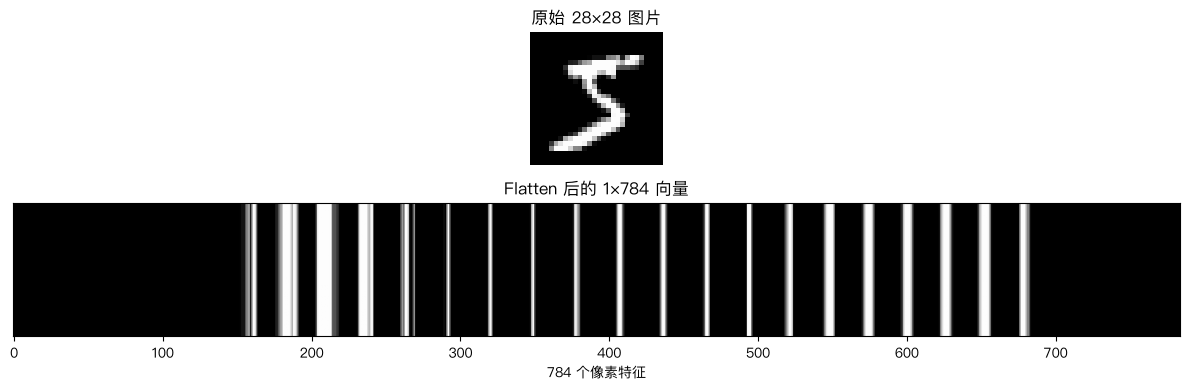

In [13]:
# ============================================================
# 第 8 步：Flatten，把 28×28 的图片拉平成 784 个数字
# ============================================================

# reshape(-1) 表示把原来的矩阵拉平成一维数组。
flatten_example = example_image_normalized.reshape(-1)

print("原始图片形状：", example_image_normalized.shape)
print("Flatten 后形状：", flatten_example.shape)

print("\nFlatten 后的前 40 个像素值：")
print(flatten_example[:40])

plt.figure(figsize=(12, 4))

plt.subplot(2, 1, 1)
plt.imshow(example_image_normalized, cmap="gray")
plt.title("原始 28×28 图片")
plt.axis("off")

plt.subplot(2, 1, 2)
plt.imshow(flatten_example.reshape(1, 784), cmap="gray", aspect="auto")
plt.title("Flatten 后的 1×784 向量")
plt.yticks([])
plt.xlabel("784 个像素特征")

plt.tight_layout()
plt.show()


# 第 9 步：构建神经网络模型

我们现在构建一个简单的神经网络：

```text
输入图片 28×28
        ↓
Flatten：拉平成 784 个数字
        ↓
Dense：128 个神经元
        ↓
Dropout：随机丢弃一部分神经元，减少过拟合
        ↓
Dense：10 个神经元
        ↓
Softmax：输出属于 0~9 每个数字的概率
```

---

## 重点：Softmax 是什么？

最后一层有 10 个神经元，对应数字 0 到 9。

Softmax 会把模型输出转换成一组概率，例如：

```text
数字 0：0.01
数字 1：0.02
数字 2：0.90
数字 3：0.01
...
```

这表示模型认为这张图片最可能是数字 2。

---

## 重要修复

下面模型里的 `name=` 全部使用英文安全命名，例如：

```python
name="flatten_28x28_to_784"
```

不要写成：

```python
name="Flatten：28×28变成784"
```

否则在部分 TensorFlow/Keras 版本中会报：

```text
not a valid scope name
```


In [ ]:
# ============================================================
# 第 9 步：构建神经网络模型
# ============================================================

# ------------------------------------------------------------
# 重要提醒：
# Keras 层的 name 不要使用中文、中文冒号、乘号等字符。
#
# 错误示例：
# layers.Flatten(name="Flatten：28×28变成784")
#
# 正确示例：
# layers.Flatten(name="flatten_28x28_to_784")
#
# 中文说明应该写在注释、Markdown、print 或图表标题中，
# 不要写在 Keras 层的 name 参数里。
# ------------------------------------------------------------

model = keras.Sequential([
    # 输入层：
    # shape=(28, 28) 表示每个输入样本是一张 28×28 的图片。
    layers.Input(shape=(28, 28), name="input_28x28_image"),

    # Flatten 层：
    # 把 28×28 的二维矩阵拉平成 784 个数字。
    layers.Flatten(name="flatten_28x28_to_784"),

    # Dense 全连接隐藏层：
    # 128 表示这一层有 128 个神经元。
    # activation="relu" 表示使用 ReLU 激活函数。
    #
    # ReLU 的直观理解：
    # 如果输入小于 0，就输出 0；
    # 如果输入大于 0，就原样输出。
    layers.Dense(128, activation="relu", name="dense_128_relu"),

    # Dropout 层：
    # 训练过程中随机让 20% 的神经元暂时失效。
    # 这可以减少模型对训练集的死记硬背，也就是减少过拟合。
    layers.Dropout(0.2, name="dropout_20_percent"),

    # 输出层：
    # 10 个神经元分别对应数字 0~9。
    # softmax 会输出 10 个概率，这 10 个概率加起来约等于 1。
    layers.Dense(10, activation="softmax", name="output_10_softmax")
])

# 编译模型：
# optimizer：优化器，负责根据损失函数调整参数。
# loss：损失函数，用来衡量预测结果和真实标签之间的差距。
# metrics：训练过程中额外观察的指标，这里观察 accuracy 准确率。
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 打印模型结构。
# 这一步可以让你看到每一层的输出形状和参数数量。
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_28x28_to_784 (Flatten)  │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128_relu (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20_percent (Dropout)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_10_softmax (Dense)       │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

# 第 9.1 步：理解模型参数数量

在 `model.summary()` 中，你会看到参数数量。

例如 Dense 层的参数数量为什么很多？

第一层 Dense 接收 784 个输入特征，输出 128 个神经元：

```text
权重数量 = 784 × 128
偏置数量 = 128
总参数量 = 784 × 128 + 128
```

这些参数一开始通常是随机的。  
模型训练的过程，本质上就是不断调整这些参数。


In [15]:
# ============================================================
# 第 9.1 步：用代码计算第一层 Dense 的参数数量
# ============================================================

input_features = 28 * 28
hidden_neurons = 128

weight_count = input_features * hidden_neurons
bias_count = hidden_neurons
total_count = weight_count + bias_count

print("输入特征数：", input_features)
print("隐藏层神经元数量：", hidden_neurons)
print("权重数量 = 784 × 128 =", weight_count)
print("偏置数量 = 128")
print("总参数数量 =", total_count)


输入特征数： 784
隐藏层神经元数量： 128
权重数量 = 784 × 128 = 100352
偏置数量 = 128
总参数数量 = 100480


# 第 10 步：训练模型

训练模型时，每一轮 `epoch` 大致会发生：

1. 模型读取一批训练图片。
2. 根据当前参数给出预测结果。
3. 把预测结果和真实标签比较，计算损失 `loss`。
4. 通过反向传播计算每个参数应该怎么调整。
5. 优化器根据这些信息更新参数。
6. 进入下一批数据，继续重复。

---

## batch_size 是什么？

这里设置：

```python
batch_size=128
```

意思是模型不是一次看完 50,000 张训练图片，而是每次看 128 张。  
每看完一小批，就更新一次参数。

---

## epoch 是什么？

这里设置：

```python
epochs=8
```

意思是整个训练集会被模型完整学习 8 遍。


In [16]:
# ============================================================
# 第 10 步：开始训练模型
# ============================================================

# 为了课堂演示速度，这里设置 epochs=8。
# 如果你想让训练更快，可以改成 3 或 5。
# 如果你想让模型稍微更充分地训练，可以改成 10。
EPOCHS = 8
BATCH_SIZE = 128

history = model.fit(
    x_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val)
)


Epoch 1/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8766 - loss: 0.4326 - val_accuracy: 0.9402 - val_loss: 0.2182
Epoch 2/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9398 - loss: 0.2080 - val_accuracy: 0.9549 - val_loss: 0.1565
Epoch 3/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9540 - loss: 0.1592 - val_accuracy: 0.9621 - val_loss: 0.1294
Epoch 4/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9625 - loss: 0.1293 - val_accuracy: 0.9662 - val_loss: 0.1123
Epoch 5/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9674 - loss: 0.1110 - val_accuracy: 0.9698 - val_loss: 0.0985
Epoch 6/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9728 - loss: 0.0936 - val_accuracy: 0.9728 - val_loss: 0.0914
Epoch 7/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9743 - loss: 0.0857 - val_accuracy: 0.9731 - val_loss: 0.0869
Epoch 8/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9773 - loss: 0.0749 - val_accuracy: 0.9748 - v

# 第 11 步：绘制训练过程曲线

训练完成后，我们不要只看最终准确率，还要观察训练过程。

主要看两类曲线：

1. `loss`：损失值，越低越好。
2. `accuracy`：准确率，越高越好。

---

## 如何观察是否过拟合？

如果出现下面情况：

```text
训练集 accuracy 越来越高
验证集 accuracy 不再提高，甚至下降
```

就可能说明模型开始过拟合。

过拟合的意思是：

> 模型在训练集上表现很好，但在没见过的新数据上表现没那么好。


history 中包含的记录： dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


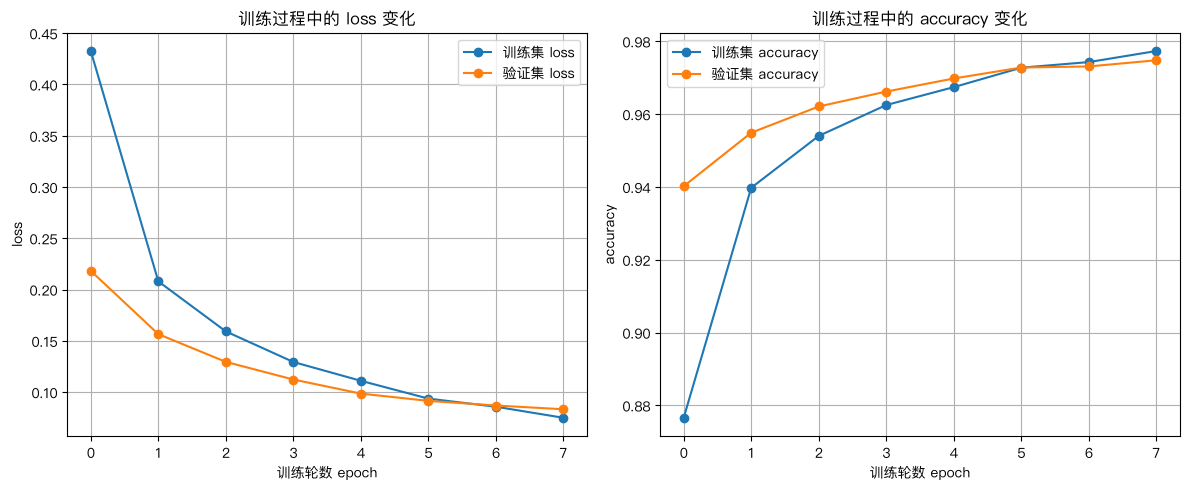

观察提示：
1. loss 越低，说明模型预测和真实答案之间的差距越小。
2. accuracy 越高，说明模型分类正确率越高。
3. 如果训练集很好但验证集变差，可能说明过拟合。


In [17]:
# ============================================================
# 第 11 步：绘制训练过程中的 loss 和 accuracy
# ============================================================

# history.history 是一个字典，里面记录了每一轮训练的指标。
history_dict = history.history

print("history 中包含的记录：", history_dict.keys())

plt.figure(figsize=(12, 5))

# ------------------------------------------------------------
# 左图：loss 变化
# ------------------------------------------------------------
plt.subplot(1, 2, 1)
plt.plot(history_dict["loss"], marker="o", label="训练集 loss")
plt.plot(history_dict["val_loss"], marker="o", label="验证集 loss")
plt.title("训练过程中的 loss 变化")
plt.xlabel("训练轮数 epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)

# ------------------------------------------------------------
# 右图：accuracy 变化
# ------------------------------------------------------------
plt.subplot(1, 2, 2)
plt.plot(history_dict["accuracy"], marker="o", label="训练集 accuracy")
plt.plot(history_dict["val_accuracy"], marker="o", label="验证集 accuracy")
plt.title("训练过程中的 accuracy 变化")
plt.xlabel("训练轮数 epoch")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("观察提示：")
print("1. loss 越低，说明模型预测和真实答案之间的差距越小。")
print("2. accuracy 越高，说明模型分类正确率越高。")
print("3. 如果训练集很好但验证集变差，可能说明过拟合。")


# 第 12 步：在测试集上评估最终效果

测试集是在训练过程中没有参与参数调整的数据。

因此，测试集表现更能代表模型面对新数据时的能力。

---

## 注意

不要用测试集反复调模型。  
否则测试集也会被你“间接用来训练”，最终评估会失真。


In [18]:
# ============================================================
# 第 12 步：使用测试集评估模型
# ============================================================

test_loss, test_accuracy = model.evaluate(x_test_normalized, y_test, verbose=0)

print(f"测试集 loss：{test_loss:.4f}")
print(f"测试集 accuracy：{test_accuracy:.4f}")
print(f"测试集准确率约为：{test_accuracy * 100:.2f}%")


测试集 loss：0.0816
测试集 accuracy：0.9755
测试集准确率约为：97.55%


# 第 13 步：观察单张图片的预测过程

现在我们选择一张测试图片，让模型预测它是什么数字。

模型最后输出的是 10 个概率：

```text
第 0 个概率：模型认为它是数字 0 的概率
第 1 个概率：模型认为它是数字 1 的概率
...
第 9 个概率：模型认为它是数字 9 的概率
```

概率最大的那个数字，就是模型最终预测结果。


真实标签： 7
模型预测： 7

模型输出的 10 个概率：
数字 0: 0.0000
数字 1: 0.0000
数字 2: 0.0000
数字 3: 0.0001
数字 4: 0.0000
数字 5: 0.0000
数字 6: 0.0000
数字 7: 0.9999
数字 8: 0.0000
数字 9: 0.0000


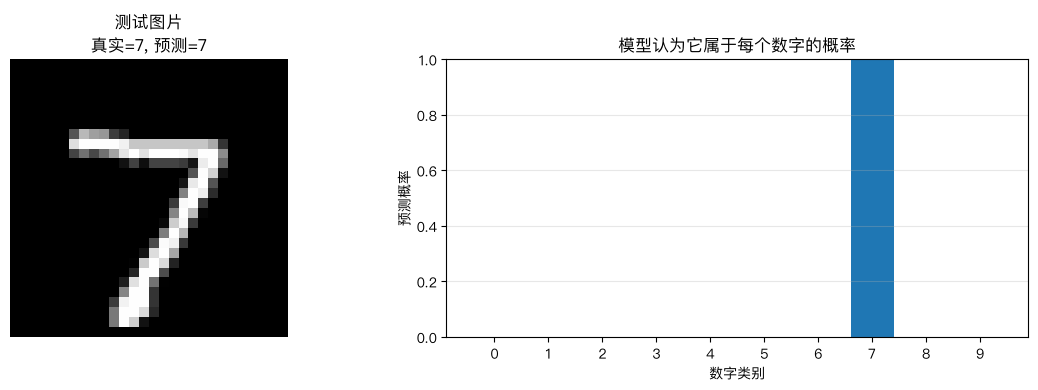

In [19]:
# ============================================================
# 第 13 步：观察模型对单张图片的预测过程
# ============================================================

# 选择测试集中的第 0 张图片。
test_index = 0

single_image = x_test_normalized[test_index]
single_label = y_test[test_index]

# model.predict() 接收的是一批数据。
# single_image 原本形状是 (28, 28)
# reshape(1, 28, 28) 后形状是 (1, 28, 28)，表示这一批里只有 1 张图片。
single_prediction = model.predict(single_image.reshape(1, 28, 28), verbose=0)[0]

# np.argmax 找到概率最大的下标。
# 因为下标 0~9 正好对应数字 0~9，所以这个下标就是预测数字。
predicted_label = np.argmax(single_prediction)

print("真实标签：", single_label)
print("模型预测：", predicted_label)

print("\n模型输出的 10 个概率：")
for digit, prob in enumerate(single_prediction):
    print(f"数字 {digit}: {prob:.4f}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(single_image, cmap="gray")
plt.title(f"测试图片\n真实={single_label}, 预测={predicted_label}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.bar(range(10), single_prediction)
plt.xticks(range(10))
plt.ylim(0, 1)
plt.title("模型认为它属于每个数字的概率")
plt.xlabel("数字类别")
plt.ylabel("预测概率")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


# 第 14 步：批量展示测试集预测结果

下面我们展示测试集中前 30 张图片的预测情况。

图中：

- 绿色标题：预测正确
- 红色标题：预测错误

这一步适合让你直观看到模型的实际识别效果。


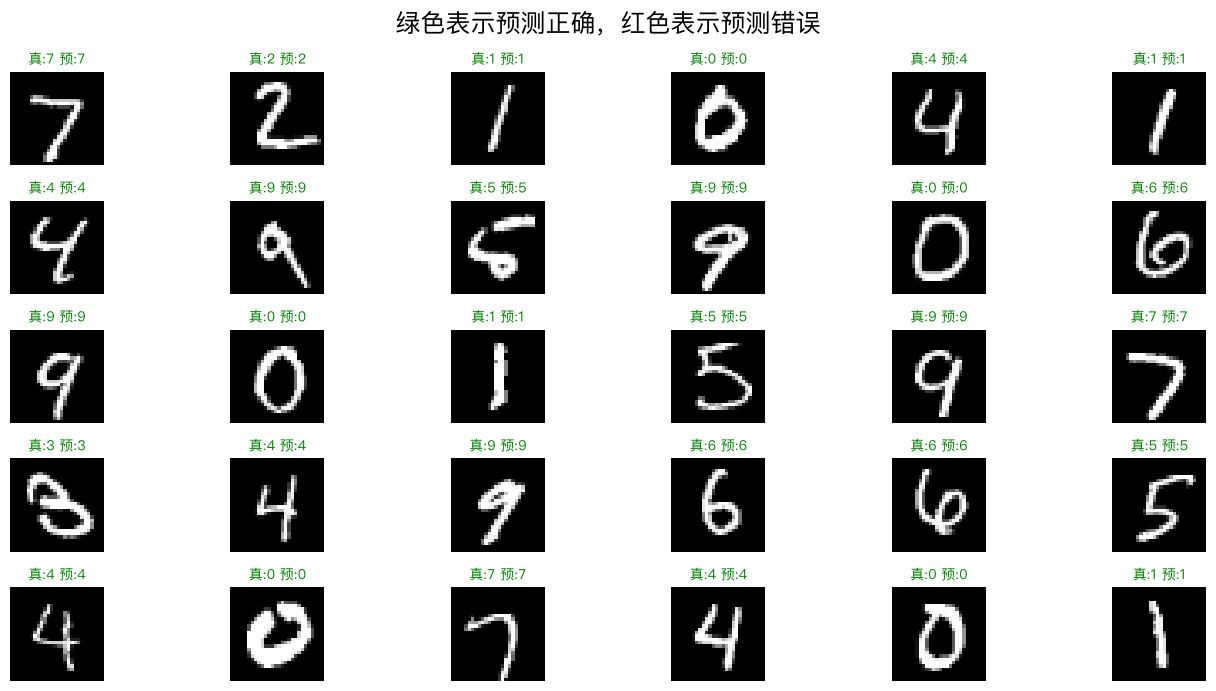

In [20]:
# ============================================================
# 第 14 步：批量展示测试集预测结果
# ============================================================

num_show = 30

# 对前 30 张测试图片进行预测。
predictions = model.predict(x_test_normalized[:num_show], verbose=0)

# 每张图片都有 10 个概率，取最大概率的位置作为预测标签。
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(14, 7))

for i in range(num_show):
    plt.subplot(5, 6, i + 1)
    plt.imshow(x_test_normalized[i], cmap="gray")

    true_label = y_test[i]
    pred_label = predicted_labels[i]

    # 如果预测正确，用绿色标题；否则用红色标题。
    title_color = "green" if true_label == pred_label else "red"

    plt.title(
        f"真:{true_label} 预:{pred_label}",
        color=title_color,
        fontsize=10
    )
    plt.axis("off")

plt.suptitle("绿色表示预测正确，红色表示预测错误", fontsize=18)
plt.tight_layout()
plt.show()


# 第 15 步：混淆矩阵

混淆矩阵可以帮助我们分析模型容易把哪些数字认错。

混淆矩阵的含义：

```text
行：真实数字
列：模型预测的数字
```

例如：

```text
第 5 行第 3 列数值较大
```

表示：

```text
真实数字是 5 的图片，经常被模型预测成 3
```

这比只看准确率更深入。


混淆矩阵：
[[ 963    0    2    1    2    2    6    1    2    1]
 [   0 1127    3    0    0    1    1    0    3    0]
 [   6    4  995    5    2    0    3   10    7    0]
 [   0    0    1  988    0    5    0    7    5    4]
 [   2    0    4    0  960    0    2    1    4    9]
 [   2    2    0    9    1  867    2    1    6    2]
 [   5    3    0    1    4    4  938    0    3    0]
 [   1    6    9    1    0    0    0 1004    1    6]
 [   2    1    2    6    5    3    3    7  941    4]
 [   2    5    0    5   10    3    1    8    3  972]]


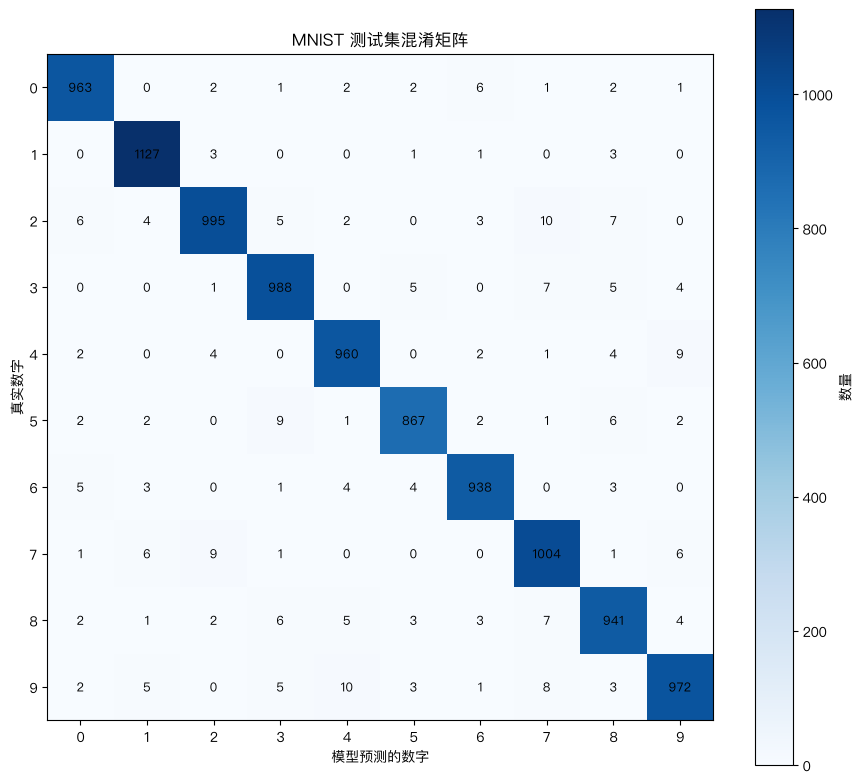

In [21]:
# ============================================================
# 第 15 步：计算并展示混淆矩阵
# ============================================================

# 对全部测试集进行预测。
all_predictions = model.predict(x_test_normalized, verbose=0)
all_predicted_labels = np.argmax(all_predictions, axis=1)

# 创建一个 10×10 的全零矩阵。
# 行表示真实标签，列表示预测标签。
confusion_matrix = np.zeros((10, 10), dtype=int)

# 统计每一种真实标签和预测标签的组合出现了多少次。
for true_label, pred_label in zip(y_test, all_predicted_labels):
    confusion_matrix[true_label, pred_label] += 1

print("混淆矩阵：")
print(confusion_matrix)

plt.figure(figsize=(9, 8))
plt.imshow(confusion_matrix, cmap="Blues")
plt.title("MNIST 测试集混淆矩阵")
plt.xlabel("模型预测的数字")
plt.ylabel("真实数字")
plt.xticks(range(10))
plt.yticks(range(10))
plt.colorbar(label="数量")

# 在每个格子中写上具体数量。
for row in range(10):
    for col in range(10):
        plt.text(
            col,
            row,
            str(confusion_matrix[row, col]),
            ha="center",
            va="center",
            color="black",
            fontsize=9
        )

plt.tight_layout()
plt.show()


# 第 16 步：展示模型预测错误的案例

模型为什么会认错？

常见原因包括：

1. 手写数字本身写得比较模糊。
2. 某些数字形状本来就相似，例如 3 和 5、4 和 9。
3. 图片中的笔画断裂或者倾斜。
4. 这个简单模型只使用了全连接网络，没有使用卷积神经网络，因此对局部图像结构的理解有限。


测试集中一共有 10000 张图片。
模型预测错误的图片数量：245
错误率约为：2.45%


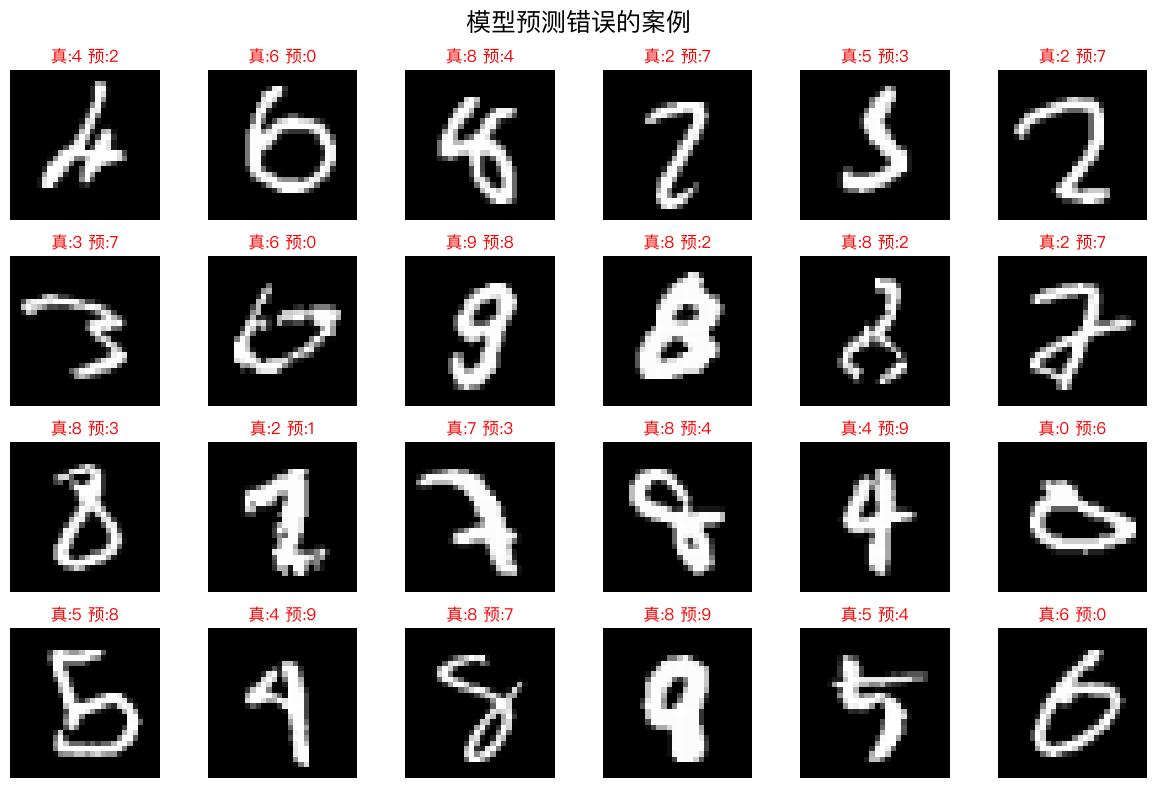

In [22]:
# ============================================================
# 第 16 步：展示模型预测错误的图片
# ============================================================

# 找到预测错误的图片索引。
wrong_indices = np.where(all_predicted_labels != y_test)[0]

print(f"测试集中一共有 {len(y_test)} 张图片。")
print(f"模型预测错误的图片数量：{len(wrong_indices)}")
print(f"错误率约为：{len(wrong_indices) / len(y_test) * 100:.2f}%")

# 最多展示 24 个错误案例。
num_wrong_show = min(24, len(wrong_indices))

plt.figure(figsize=(12, 8))

for i in range(num_wrong_show):
    idx = wrong_indices[i]

    plt.subplot(4, 6, i + 1)
    plt.imshow(x_test_normalized[idx], cmap="gray")

    true_label = y_test[idx]
    pred_label = all_predicted_labels[idx]

    plt.title(f"真:{true_label} 预:{pred_label}", color="red")
    plt.axis("off")

plt.suptitle("模型预测错误的案例", fontsize=18)
plt.tight_layout()
plt.show()


# 第 17 步：额外演示 Softmax 输出

Softmax 输出层的 10 个数可以理解为：

```text
模型对每个数字类别的信心
```

这些概率加起来约等于 1。

我们可以选择几张测试图片，同时展示图片和它们的预测概率分布。


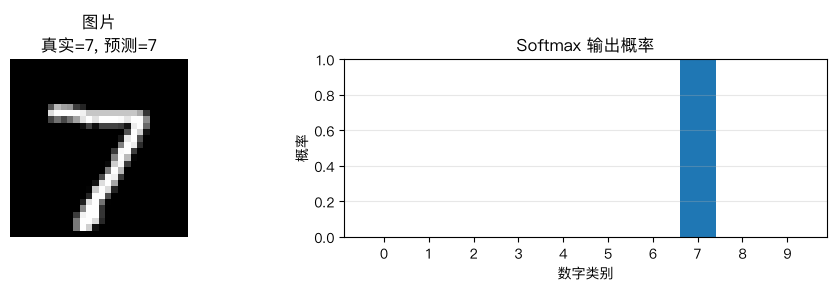

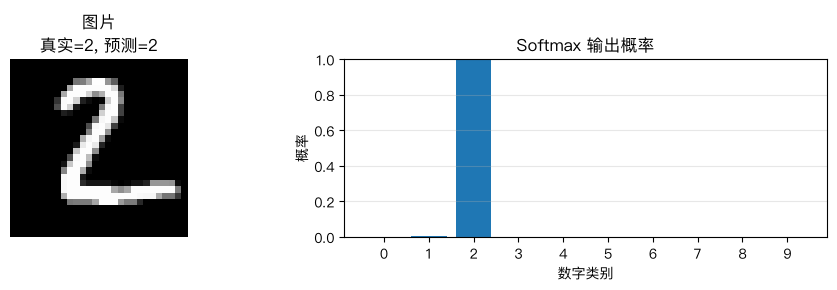

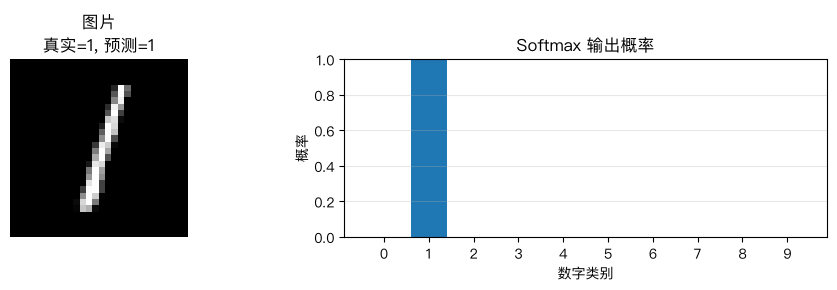

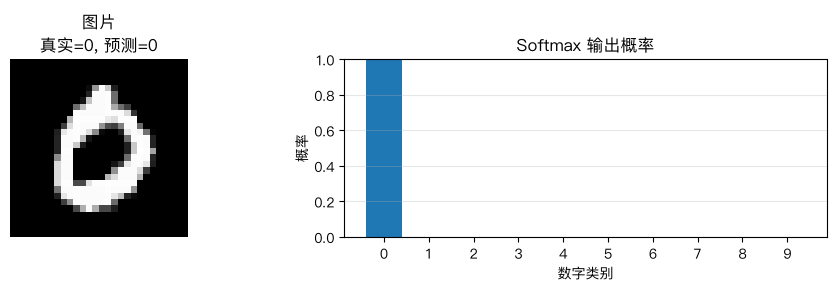

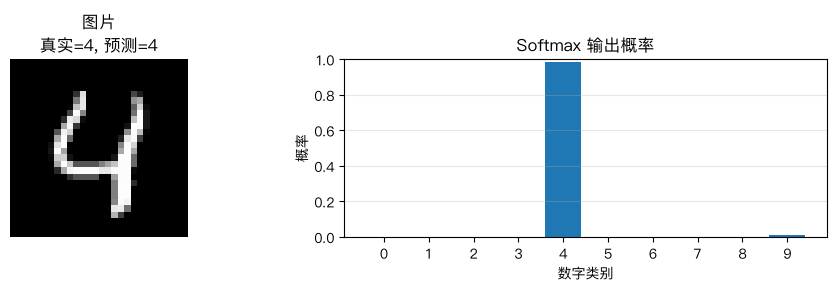

In [23]:
# ============================================================
# 第 17 步：额外展示多张图片的 Softmax 概率分布
# ============================================================

# 选择几张图片进行展示。
indices_to_show = [0, 1, 2, 3, 4]

for idx in indices_to_show:
    image = x_test_normalized[idx]
    true_label = y_test[idx]

    probs = model.predict(image.reshape(1, 28, 28), verbose=0)[0]
    pred_label = np.argmax(probs)

    plt.figure(figsize=(10, 3))

    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap="gray")
    plt.title(f"图片\n真实={true_label}, 预测={pred_label}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.bar(range(10), probs)
    plt.xticks(range(10))
    plt.ylim(0, 1)
    plt.title("Softmax 输出概率")
    plt.xlabel("数字类别")
    plt.ylabel("概率")
    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


# 第 18 步：总结

本案例完整展示了手写数字识别的基本流程。

---

## 可以总结成这几句话

1. 图片在计算机中不是“图片”，而是数字矩阵。
2. MNIST 中一张图片是 28×28 的灰度矩阵。
3. 每个像素点都是一个数值。
4. 归一化可以把像素值从 0~255 压缩到 0~1。
5. Flatten 可以把 28×28 的矩阵拉平成 784 个输入特征。
6. 神经网络通过训练不断调整参数。
7. Softmax 输出 10 个概率，分别对应数字 0 到 9。
8. 概率最大的类别就是模型最终预测的数字。
9. 准确率可以告诉我们整体表现。
10. 混淆矩阵和错误案例可以帮助我们分析模型哪里容易出错。

---

## 最核心的一句话

> 手写数字识别不是计算机真正“看懂”了数字，而是它从大量像素矩阵和标签中，学习到了不同数字的像素分布规律。
